# Naive Bayes

In [5]:
from scipy.sparse import load_npz
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    RocCurveDisplay
)
from sklearn.naive_bayes import MultinomialNB
import pandas as pd
import time

Se carga dataset.

In [6]:
X_train = load_npz('datasets/X_train.npz')
X_test = load_npz('datasets/X_test.npz')
y_train = pd.read_csv('datasets/y_train.csv')['label']
y_test = pd.read_csv('datasets/y_test.csv')['label']

Se inicializa Naive Bayes con su implementación `MultinomialNB` que, según la documentación, funciona bien con datasets de TF-IDF como el nuestro, y se prueba.

In [7]:
nb_model = MultinomialNB()

start_train_time = time.time()
nb_model.fit(X_train, y_train)
end_train_time = time.time()

train_duration = end_train_time - start_train_time

start_predict_duration = time.time()
y_pred = nb_model.predict(X_test)
end_predict_duration = time.time()

predict_duration = end_predict_duration - start_predict_duration

### Métricas

Se evalúa.

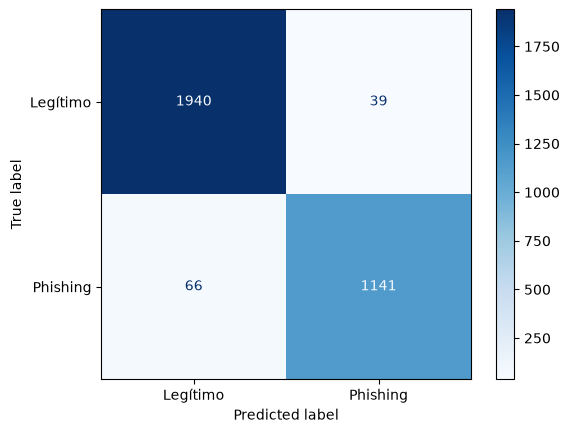

In [8]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [9]:
cm_nb = confusion_matrix(y_test, y_pred)
P = cm_nb[1, :].sum()
N = cm_nb[0, :].sum()
TP = cm_nb[1, 1]
TN = cm_nb[0, 0]

TPR_nb = TP / P
TNR_nb = TN / N
balanced_accuracy_nb = (TPR_nb + TNR_nb) / 2

precision_nb = precision_score(y_test, y_pred, zero_division=0)
recall_nb = recall_score(y_test, y_pred, zero_division=0)
f1_nb = f1_score(y_test, y_pred, zero_division=0)

print(f"Exactitud balanceada:    {balanced_accuracy_nb:.4f}")
print(f"Precisión:               {precision_nb:.4f}")
print(f"Sensibilidad (Recall):   {TPR_nb:.4f}")
print(f"F1-score:                {f1_nb:.4f}")
print(f"Especificidad:           {TNR_nb:.4f}")
print(f"Recuperación (Recall):   {recall_nb:.4f}")
print(f"Tiempo de entrenamiento: {train_duration:.4f}")
print(f"Tiempo de predicción:    {predict_duration:.4f}")

Exactitud balanceada:    0.9628
Precisión:               0.9669
Sensibilidad (Recall):   0.9453
F1-score:                0.9560
Especificidad:           0.9803
Recuperación (Recall):   0.9453
Tiempo de entrenamiento: 0.0200
Tiempo de predicción:    0.0025


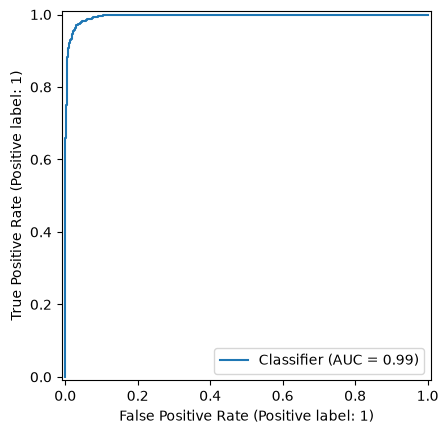

In [10]:
y_scores = nb_model.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_scores)

**Nota sobre las features utilizadas:** a diferencia de los demás modelos evaluados (que usarán TF-IDF + las extra features `word_count`, `has_link` y `words_count_cat`), este baseline utiliza únicamente la matriz TF-IDF. Esto se debe a que `MultinomialNB` requiere features no negativas, y `word_count` fue escalado con `StandardScaler`, lo cual puede generar valores negativos incompatibles con este modelo. Por lo tanto, la comparación de este baseline contra los demás modelos no es estrictamente en igualdad de condiciones de features, aunque sí sirve como referencia de piso razonable a superar.

**Nota para conclusiones:** el dataset `Phishing_Email.csv` combina emails legítimos provenientes del corpus de Enron con emails de phishing de otra fuente (se observó en el EDA que "enron" y "ect" están entre las palabras más frecuentes). Esto podría hacer que los modelos aprendan a distinguir el "estilo Enron" en lugar de patrones genuinos de phishing (urgencia, links sospechosos, etc.), lo que podría inflar artificialmente las métricas de performance. Vale la pena tenerlo en cuenta si todos los modelos terminan con resultados muy altos y parejos.